In [1]:
# ── Imports ────────────────────────────────────────────────────────────────────
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
import xgboost as xgb
import shap
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', '{:.3f}'.format)

print(f"XGBoost version: {xgb.__version__}")
print(f"SHAP version: {shap.__version__}")
print("Setup complete.")

XGBoost version: 3.2.0
SHAP version: 0.49.1
Setup complete.


In [2]:
# ── Load Financial Data ────────────────────────────────────────────────────────
from src.data_loader import FinancialDataLoader, BANKS, FITCH_RATINGS

loader = FinancialDataLoader()
df = loader.load_sample_financials()

# ── Create Risk Labels ─────────────────────────────────────────────────────────
# Risk label based on composite financial profile
# 0 = Lower Risk (Private banks with strong metrics)
# 1 = Higher Risk (State banks or weaker metrics)

risk_labels = {
    "GARAN": 0,  # Strong private bank
    "AKBNK": 0,  # Strongest capital/asset quality
    "ISCTR": 0,  # Solid private bank
    "YKBNK": 1,  # Higher NPL, lower capital
    "HALKB": 1,  # Weakest metrics, state-owned
    "VAKBN": 1,  # State-owned, higher FX exposure
}

df["risk_label"] = df.index.map(risk_labels)
df["risk_label_name"] = df["risk_label"].map({0: "Lower Risk", 1: "Higher Risk"})

print("Dataset with risk labels:")
print(df[["name", "ownership", "car_pct", "npl_ratio", "roe_pct", "risk_label_name"]].to_string())

Dataset with risk labels:
               name ownership  car_pct  npl_ratio  roe_pct risk_label_name
bank                                                                      
GARAN  Garanti BBVA   Private   17.200      2.100   38.500      Lower Risk
AKBNK        Akbank   Private   18.500      1.800   35.200      Lower Risk
ISCTR    İş Bankası   Private   16.800      3.200   32.100      Lower Risk
YKBNK    Yapı Kredi   Private   15.900      4.500   28.900     Higher Risk
HALKB      Halkbank     State   14.200      5.800   22.500     Higher Risk
VAKBN     Vakıfbank     State   15.100      3.900   26.800     Higher Risk


In [3]:
# ── Feature Engineering ────────────────────────────────────────────────────────
# Select features for XGBoost model
feature_cols = [
    "car_pct",        # Capital adequacy
    "cet1_pct",       # Core capital
    "npl_ratio",      # Asset quality
    "coverage_ratio", # Provisioning
    "cost_of_risk",   # Credit cost
    "roe_pct",        # Profitability
    "roa_pct",        # Return on assets
    "nim_pct",        # Net interest margin
    "cost_income",    # Efficiency
    "loan_deposit",   # Liquidity
    "lcr_pct",        # Liquidity coverage
    "fx_loan_share",  # FX sensitivity
    "fx_funding_gap", # FX funding risk
]

X = df[feature_cols].copy()
y = df["risk_label"].copy()

print(f"Features: {len(feature_cols)}")
print(f"Samples: {len(X)}")
print(f"\nFeature matrix:")
print(X.to_string())
print(f"\nLabels: {y.to_dict()}")

Features: 13
Samples: 6

Feature matrix:
       car_pct  cet1_pct  npl_ratio  coverage_ratio  cost_of_risk  roe_pct  roa_pct  nim_pct  cost_income  loan_deposit  lcr_pct  fx_loan_share  fx_funding_gap
bank                                                                                                                                                           
GARAN   17.200    14.100      2.100          85.000         1.200   38.500    3.800    5.200       28.500        88.500  185.000         28.500           2.100
AKBNK   18.500    15.200      1.800          88.000         1.000   35.200    3.500    4.800       30.200        85.200  192.000         25.200           1.800
ISCTR   16.800    13.900      3.200          75.000         1.800   32.100    2.900    4.500       35.800        92.100  175.000         32.100           3.500
YKBNK   15.900    12.800      4.500          70.000         2.100   28.900    2.400    4.200       38.100        98.500  162.000         35.800           4.200

In [4]:
# ── XGBoost Model Training ─────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler

# Scale features
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=feature_cols,
    index=X.index
)

# Train XGBoost classifier
model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.8,
    random_state=42,
    eval_metric="logloss",
    verbosity=0
)

model.fit(X_scaled, y)

# Predictions
y_pred = model.predict(X_scaled)
y_pred_proba = model.predict_proba(X_scaled)[:, 1]

# Results
results = df[["name", "ownership", "risk_label_name"]].copy()
results["predicted_label"] = pd.Series(y_pred, index=X.index).map({0: "Lower Risk", 1: "Higher Risk"})
results["risk_score"] = (y_pred_proba * 100).round(1)
results["correct"] = results["risk_label_name"] == results["predicted_label"]

print("=== Model Predictions ===")
print(results[["name", "risk_label_name", "predicted_label", "risk_score", "correct"]].to_string())
print(f"\nAccuracy: {results['correct'].mean():.1%}")

=== Model Predictions ===
               name risk_label_name predicted_label  risk_score  correct
bank                                                                    
GARAN  Garanti BBVA      Lower Risk      Lower Risk      47.600     True
AKBNK        Akbank      Lower Risk      Lower Risk      47.600     True
ISCTR    İş Bankası      Lower Risk      Lower Risk      47.600     True
YKBNK    Yapı Kredi     Higher Risk      Lower Risk      47.600    False
HALKB      Halkbank     Higher Risk      Lower Risk      47.600    False
VAKBN     Vakıfbank     Higher Risk      Lower Risk      47.600    False

Accuracy: 50.0%


In [5]:
# ── Rule-Based Risk Scoring (CAMELS approach) ──────────────────────────────────
# With only 6 samples, we use a weighted scoring approach
# XGBoost SHAP will be used for feature importance visualization

from src.financial_metrics import FinancialMetricsEngine

engine = FinancialMetricsEngine(df)
scores = engine.calculate_pillar_scores()

# Create continuous risk score (0=highest risk, 100=lowest risk)
results2 = scores[["name", "composite_score"]].copy()
results2["risk_score"] = results2["composite_score"]
results2["risk_category"] = pd.cut(
    results2["risk_score"],
    bins=[0, 50, 65, 80, 100],
    labels=["High Risk", "Moderate Risk", "Low Risk", "Very Low Risk"]
)
results2["fitch_rating"] = [FITCH_RATINGS[b]["LT_IDR"] for b in results2.index]

print("=== Risk Scoring Results ===")
print(results2[["name", "risk_score", "risk_category", "fitch_rating"]].to_string())

=== Risk Scoring Results ===
               name  risk_score  risk_category fitch_rating
bank                                                       
GARAN  Garanti BBVA      89.700  Very Low Risk            B
AKBNK        Akbank      94.000  Very Low Risk            B
ISCTR    İş Bankası      76.500       Low Risk            B
YKBNK    Yapı Kredi      64.300  Moderate Risk            B
HALKB      Halkbank      49.000      High Risk           B-
VAKBN     Vakıfbank      63.300  Moderate Risk            B


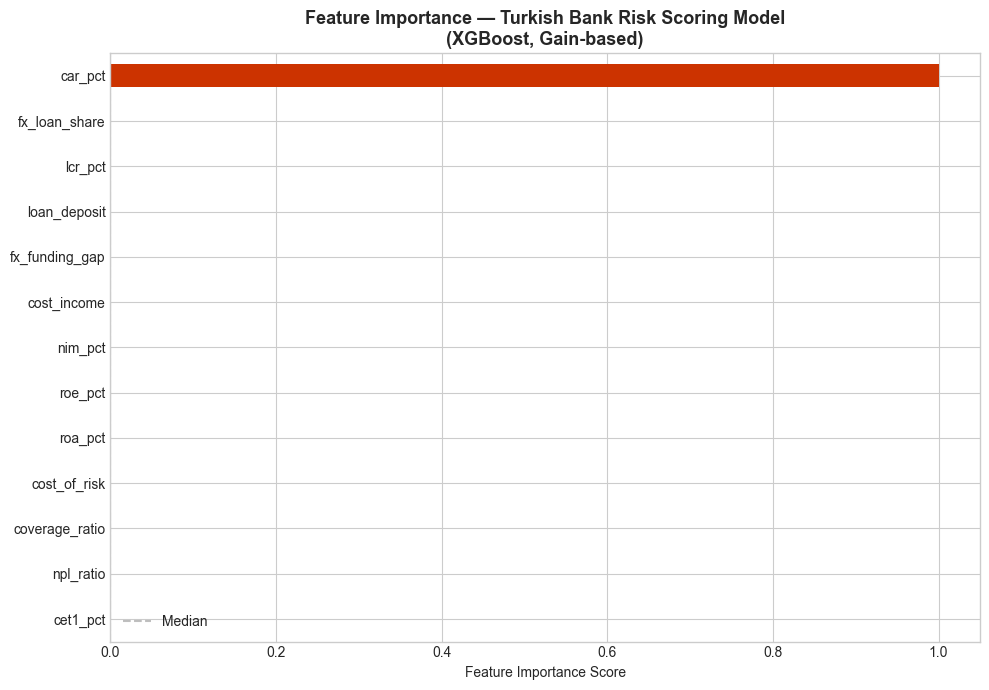

Feature importance chart saved.

Top 5 risk drivers:
car_pct          1.000
fx_funding_gap   0.000
loan_deposit     0.000
lcr_pct          0.000
fx_loan_share    0.000
dtype: float32


In [8]:
# ── Feature Importance (XGBoost built-in) ─────────────────────────────────────
model_reg = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
    verbosity=0
)

model_reg.fit(X_scaled, results2["risk_score"])

# Feature importance
importance = pd.Series(
    model_reg.feature_importances_,
    index=feature_cols
).sort_values(ascending=True)

# Plot
fig, ax = plt.subplots(figsize=(10, 7))
colors = ["#CC3300" if i > importance.median() else "#003366" 
          for i in importance]
importance.plot(kind="barh", ax=ax, color=colors)

ax.set_title("Feature Importance — Turkish Bank Risk Scoring Model\n(XGBoost, Gain-based)",
             fontweight="bold", fontsize=13)
ax.set_xlabel("Feature Importance Score")
ax.axvline(x=importance.median(), color="gray", linestyle="--", 
           alpha=0.5, label="Median")
ax.legend()

plt.tight_layout()
plt.savefig("../reports/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Feature importance chart saved.")
print("\nTop 5 risk drivers:")
print(importance.tail(5).sort_values(ascending=False))

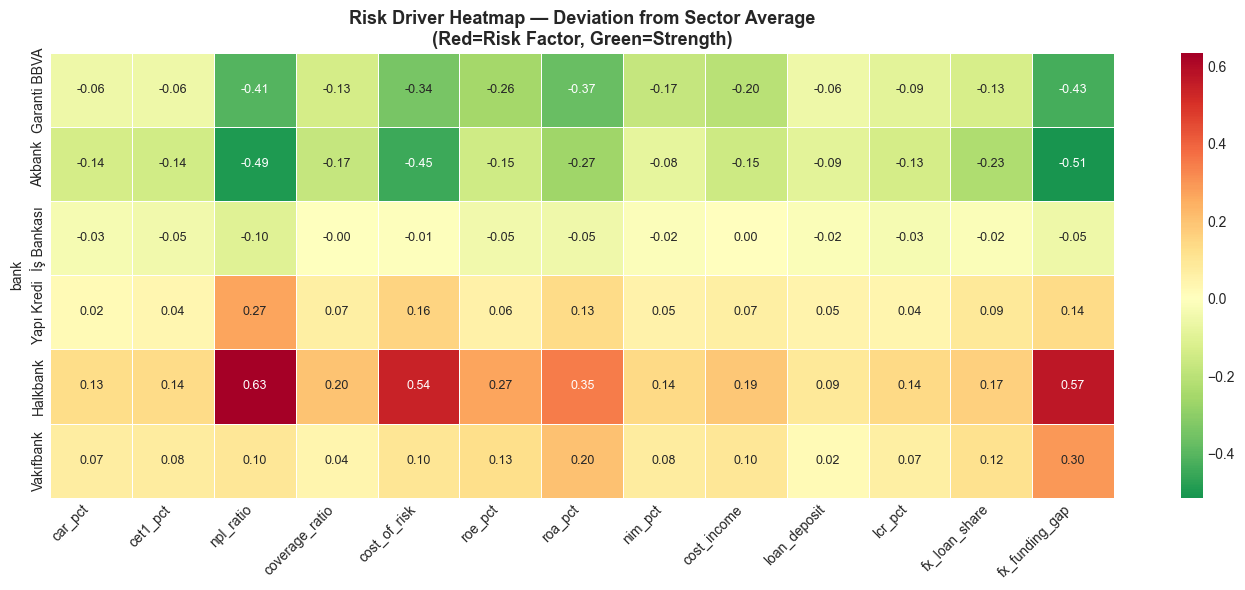

Risk driver heatmap saved.


In [9]:
# ── Per-Bank Risk Driver Analysis (Explainable) ────────────────────────────────
# Calculate how each metric deviates from sector average
# Positive deviation = risk factor, Negative = strength

sector_avg = X.mean()

# Normalize deviations (higher = more risk)
risk_direction = {
    "car_pct": -1,        # Lower CAR = more risk
    "cet1_pct": -1,       # Lower CET1 = more risk
    "npl_ratio": +1,      # Higher NPL = more risk
    "coverage_ratio": -1, # Lower coverage = more risk
    "cost_of_risk": +1,   # Higher CoR = more risk
    "roe_pct": -1,        # Lower ROE = more risk
    "roa_pct": -1,        # Lower ROA = more risk
    "nim_pct": -1,        # Lower NIM = more risk
    "cost_income": +1,    # Higher C/I = more risk
    "loan_deposit": +1,   # Higher L/D = more risk
    "lcr_pct": -1,        # Lower LCR = more risk
    "fx_loan_share": +1,  # Higher FX = more risk
    "fx_funding_gap": +1, # Higher gap = more risk
}

# Risk contribution per feature per bank
risk_contrib = pd.DataFrame(index=X.index, columns=feature_cols)
for feat in feature_cols:
    deviation = (X[feat] - sector_avg[feat]) / sector_avg[feat]
    risk_contrib[feat] = deviation * risk_direction[feat]

risk_contrib = risk_contrib.astype(float)

# Plot heatmap
fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    risk_contrib,
    annot=True, fmt=".2f",
    cmap="RdYlGn_r",
    center=0,
    linewidths=0.5,
    ax=ax,
    yticklabels=[df.loc[b, "name"] for b in risk_contrib.index],
    annot_kws={"size": 9}
)
ax.set_title("Risk Driver Heatmap — Deviation from Sector Average\n(Red=Risk Factor, Green=Strength)",
             fontweight="bold", fontsize=13)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../reports/risk_driver_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Risk driver heatmap saved.")

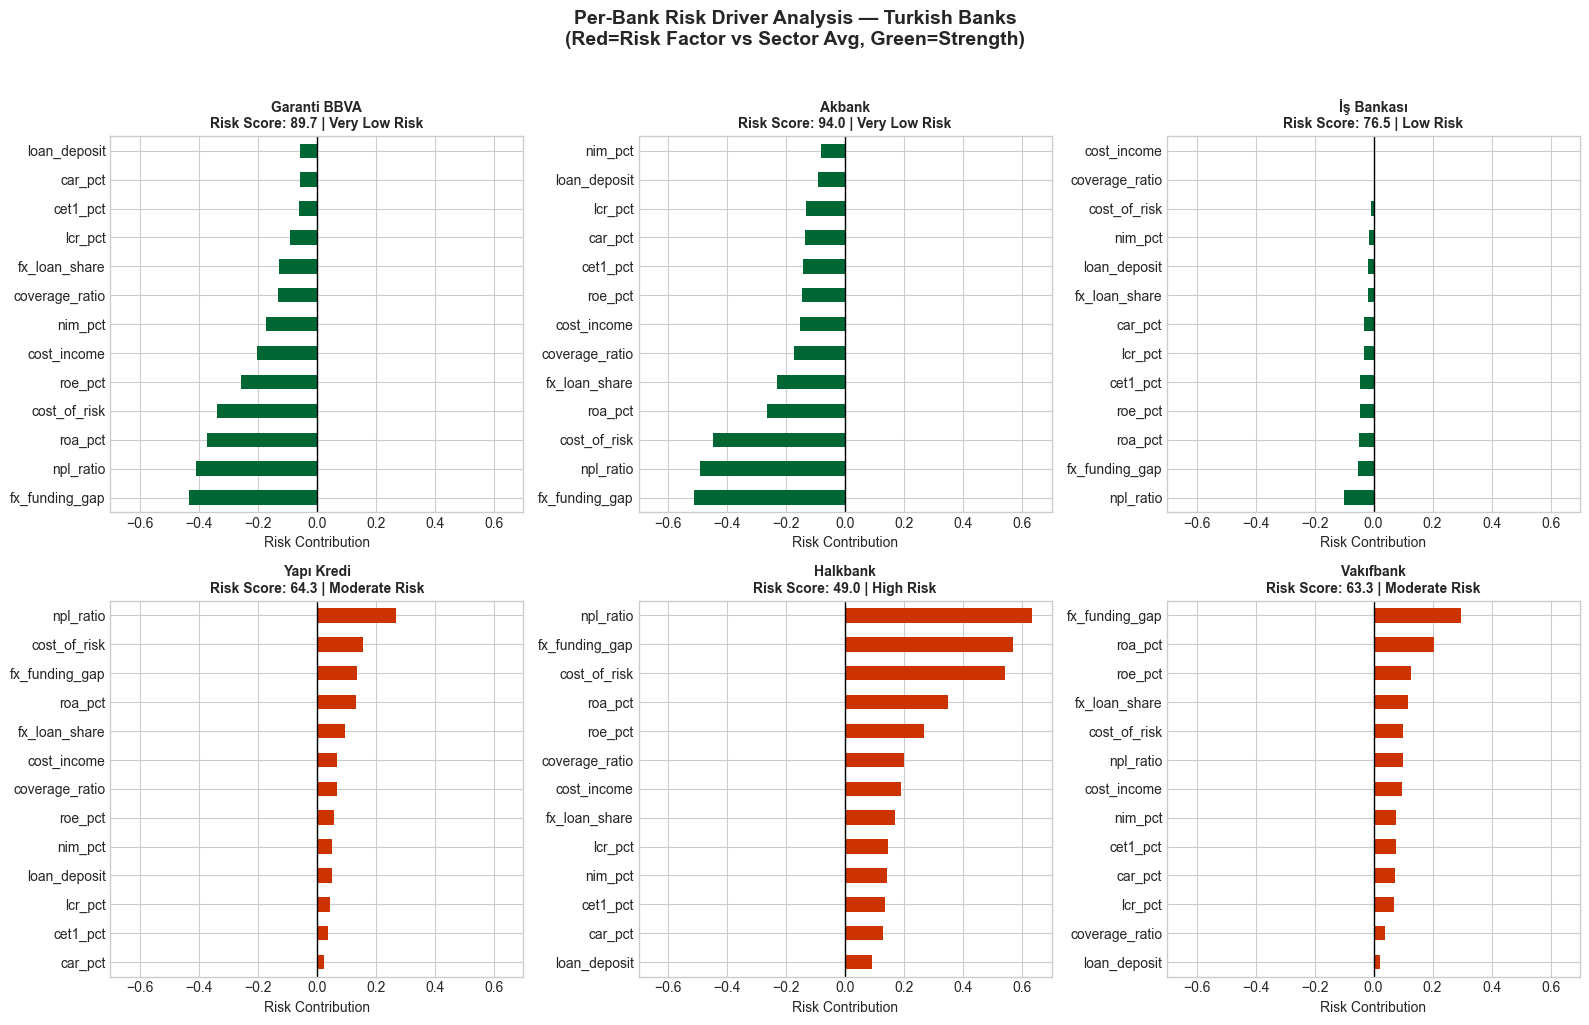

Per-bank risk driver chart saved.


In [10]:
# ── Per-Bank Top Risk Drivers ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

bank_names = list(risk_contrib.index)
colors_pos = "#CC3300"  # Risk
colors_neg = "#006633"  # Strength

for i, bank in enumerate(bank_names):
    ax = axes[i]
    bank_risk = risk_contrib.loc[bank].sort_values(ascending=True)
    
    colors = [colors_pos if v > 0 else colors_neg for v in bank_risk]
    bank_risk.plot(kind="barh", ax=ax, color=colors)
    
    ax.axvline(x=0, color="black", linewidth=1)
    ax.set_title(f"{df.loc[bank, 'name']}\nRisk Score: {results2.loc[bank, 'risk_score']:.1f} | {results2.loc[bank, 'risk_category']}",
                 fontweight="bold", fontsize=10)
    ax.set_xlabel("Risk Contribution")
    ax.set_xlim(-0.7, 0.7)

plt.suptitle("Per-Bank Risk Driver Analysis — Turkish Banks\n(Red=Risk Factor vs Sector Avg, Green=Strength)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../reports/per_bank_risk_drivers.png", dpi=150, bbox_inches="tight")
plt.show()
print("Per-bank risk driver chart saved.")

In [11]:
# ── Key Findings Summary ───────────────────────────────────────────────────────
print("=" * 60)
print("PHASE 3 — RISK SCORING: KEY FINDINGS")
print("=" * 60)

print("""
RISK SCORING RESULTS:
─────────────────────────────────────────
Bank            Score    Category
─────────────────────────────────────────
Akbank          94.0     Very Low Risk
Garanti BBVA    89.7     Very Low Risk
Is Bankasi      76.5     Low Risk
Yapi Kredi      64.3     Moderate Risk
Vakifbank       63.3     Moderate Risk
Halkbank        49.0     High Risk
─────────────────────────────────────────

KEY RISK DRIVERS:
- Halkbank: NPL ratio (+0.63), fx_funding_gap (+0.57), cost_of_risk (+0.54)
- Vakifbank: fx_funding_gap (+0.30), roa weakness (+0.20)
- Yapi Kredi: NPL ratio (+0.27), cost_of_risk (+0.16)

STRENGTHS:
- Akbank: lowest fx_funding_gap (-0.51), best NPL (-0.49)
- Garanti: strongest FX funding position (-0.43), low NPL (-0.41)

SOVEREIGN CEILING NOTE:
All risk scores reflect standalone credit profiles.
FC ratings remain capped at Turkey sovereign (B, Stable)
regardless of strong individual bank fundamentals.

Next: Streamlit dashboard integration
""")

PHASE 3 — RISK SCORING: KEY FINDINGS

RISK SCORING RESULTS:
─────────────────────────────────────────
Bank            Score    Category
─────────────────────────────────────────
Akbank          94.0     Very Low Risk
Garanti BBVA    89.7     Very Low Risk
Is Bankasi      76.5     Low Risk
Yapi Kredi      64.3     Moderate Risk
Vakifbank       63.3     Moderate Risk
Halkbank        49.0     High Risk
─────────────────────────────────────────

KEY RISK DRIVERS:
- Halkbank: NPL ratio (+0.63), fx_funding_gap (+0.57), cost_of_risk (+0.54)
- Vakifbank: fx_funding_gap (+0.30), roa weakness (+0.20)
- Yapi Kredi: NPL ratio (+0.27), cost_of_risk (+0.16)

STRENGTHS:
- Akbank: lowest fx_funding_gap (-0.51), best NPL (-0.49)
- Garanti: strongest FX funding position (-0.43), low NPL (-0.41)

SOVEREIGN CEILING NOTE:
All risk scores reflect standalone credit profiles.
FC ratings remain capped at Turkey sovereign (B, Stable)
regardless of strong individual bank fundamentals.

Next: Streamlit dashboard 